# Car Racing with Reinforcement Learning 

> **TODO  -- pequeno paragrafo de introducao do ambiente**

## Customizing the environment

### Environment understanding
First things first, we took the time to understand the underlying forces at play in this environment. The following are the collected insights:
- **Action Space - Discrete vs Continuous**: This environment has, by default, a continuous action space (p.e.: steering $s \in [-1, 1]$). However, it can be converted to a discrete action space (p.e. by only allowing full left or full right steering).

- **Friction**: As per the environment implementation, friction is a vector applied in the oposite direction of the moving car and proportional to its current speed.

- **Grip**: Describes the adherence of the car to the track. If the rear wheels angle to the cars current moving direction is too great, especially at high speeds, it will lose grip, and enter a **drifting motion**.

Moreover, by reading the environment source code (available under [car_racing.py](https://github.com/Farama-Foundation/Gymnasium/blob/main/gymnasium/envs/box2d/car_racing.py) and [car_dynamics.py](https://github.com/Farama-Foundation/Gymnasium/blob/main/gymnasium/envs/box2d/car_dynamics.py)), we found that:

- The track itself is made out of tiles, which are squares with coordinates and rotation variables. They are held in a list in the `CarRacing` class, under `self.track`. Knowing this may make it possible to calculate the line with minimum curvature (ideal trajectory).

- Each wheel in `car.wheels` *knows* if it is over one or more road tiles. This is done by checking `len(wheel.tiles)`

### Initial reward modifications
We have noticed that the reward function (as described [here](https://gymnasium.farama.org/environments/box2d/car_racing/#rewards)) is very shallow, in the sense that it encourages process (by rewarding per tile completed) but does not encourage any type of behaviour to acheive that progress. As such, we plan to implement the following modifications:

- **Gas Bias**: Pushing forward must be encouraged. As such, and to counteract the early training association<br>
`moving = crashing`, a small reward will be provided for pushing Gas.

- **Wiggle Protection**: Often a model trained on these sorts of environments will perform what is called **intentional wiggling**. That is when, in a curve, for example, the car switches sharply and repeatedly between right-steering and left-steering. This is a technique learnt by models to ensure car grip. It also is, however, a strategy that exploits simple environments, including `CarRacing-v3`, in which steering does not lose speed. To prevent this, sharply changing steering direction will have a moderate penalty.

- **Off-road Penalty**: As described below under *Aditional modifications* the simulation will be truncated shortly after the car leaves the track, if it does not return quickly. However, giving a truncation a flat penalty does not seem appropriate, since it gives no context or warning

### PID Controller-like reward system
In the autonomous racing industry, dynamic error correction is a common theme. The industry standard for such systems is what is called a **PID Controller**. This means taking into account, and trying to correct the error of degree *d* according to its original function (Proportional factor), its derivative  (Differential factor) and its integral (Integral factor). Knowing this the following reward factors were implemented, aditionally to the previous ones:

- **Optimal Line Closeness (P factor)**: In a realistic environment, turning, even while accelerating, causes *some* speed loss. Because of this, the optimal line is the one with less curvature, that is, the one where the driver minimizes steering along the whole track. Having that in mind we applied **Laplacian Smoothing** to all tile coordinates, in order to generate that optimal line, and reward the agent for **traversing** the line (**not** for standing still close to it).

- **Line Angle Minimization Reward (D factor)**: Velocity is the derivative of position. So, by looking to a cars linear velocity, one can deduce where (and how fast) it will go in the next few moments. Thereby, if the cars current linear velocity vector has a great angle difference to the tracks optimal line, it will deviate very fast, and should correct itself as soon as possible. Because of this, a reward is given to the driver as to encourage angle difference minimization. This, at the very least, dampens the drivers **"Snaking"** along the imaginary line.

### Aditional modifications

- **Early stopping**: Prevents the simulation from going on when the car has either deviated too far out of the track, leaving it aimlessly wandering around, or has been immobile for too long. Aims to quicken the training speed and make training timesteps more efficient.

- **HUD removal**: The original box shape (96x96) includes the HUD, displaying bars corresponding to the current action (steering, gas and break). Passing these cluster of pixels effectively represents either redundancy or noise to the model, both of which may impact performance. Consequently, the bottom 12px are cut, leaving the observation space a 84x96 box.

- **Grayscale filter**: Maps the RGB colour scheme of the screen to a grayscale, thus vastly reducing the amount of information and accelerating training and testing speeds.

- **Frame stacking**: In this environment, there is no visual indication of how fast the car is currently going. As such, for each model prediction (and also in training), a stack of the 4 last frames is passed.

---

All these implementations (and others which will be mentioned later in this report) can be viewed in [customization.py](customization.py).

## Reinforcement Learning Agent
Having customized the environment to our needs (namely the reward function), we moved on to choosing the reinforcement learning algorithm. We aim to choose a model, and improve it as best we can.

As both our input and output are **Continuous**, and choosing to implement a On-Policy model, we are left with 3 options: PPO, AC3 and TRPO. After careful consideration, and being commonly known as the "Jack of All Trades" regarding to reinforcement learning, we chose to implement **Proximal Policy Optimization (PPO)**.

### PPO (Proximal Policy Optimization)
> **TODO -- Small text explaining overall PPO**

#### Main starting hyperparameters

- `policy = "CnnPolicy"`: Since the Car Racing environment observation space is, essentially, a stack of images, a CNN is the most appropriate choice.

- `use_sde = True`: (g)SDE or Generalized State-Dependent Exploration is an advanced exploration strategy for Deep Reinforcement Learning (especially algorithms like PPO and A2C) designed to make the agent's actions smoother and more consistent over time. It replaces the standard "random jitter" noise with a **"structured" noise** that depends on the state of the environment. This helps in environments that mimic physics related problems by "directing" its exploration consistently throughout an episode, avoiding rapidly changing inputs in instances where only longer, consistent ones have measurable outcomes.

- `n_steps = 2048`: CarRacing requires long-horizon planning, as a single lap takes many frames to complete. Setting the rollout buffer to 2048 ensures that each update contains data from complete or nearly complete driving trajectories. This allows the algorithm to capture the delayed consequences of actions—such as how braking before a turn allows the car to survive through the turn.

- `gamma = 0.99`: This discount factor effectively gives the agent a planning horizon of roughly 100 steps. In a physics-based racing environment, the agent must value future survival (staying on track) over immediate gratification (maximum speed). A high gamma forces the policy to learn that slowing down now is necessary to maximize the reward accumulated over the rest of the track.

- `n_epochs = 10`: A value that appropriately balances the PPOs *On-Policy* approach and the complexity (both computational and environmental) of *CarRacing-v3*.

- `gae_lambda = 0.95`: Generalized Advantage Estimation (GAE) balances bias and variance in trajectory evaluation. The lower the values, the more the reward signal is smoothed out, effectively helping the agent in learning a *trend* instead of overreacting to a specific reward spike. Furthermore, values $\lambda \in [0.92, 0.98]$ are optimal for 2D physics-based environments, as verified in [this paper](https://arxiv.org/pdf/1506.02438).

- `clip_range = 0.2`: Continuous control tasks require fine motor adjustments. This parameter limits the divergence between the new and old policy to 20%, ensuring that updates do not drastically alter the steering or acceleration behavior in a single step. This prevents "policy collapse," where the car might suddenly forget how to drive straight after a bad update.

#### Other hyperparameters

- `learning_rate = 3e-4`

- `batch_size = 64`

- `vf_coef = 0.5`

- `ent_coef = 0.01`

---

These hyperparameters and all other training variables, including reward weights, can be viewed in [config.py](config.py) 

### Iterative Improvements
Having defined the initial model hyperparameters, we started training. Two training sizes were defined: 250_000 steps for debugging/testing and 2_000_000 for actual training (step number may be different for phase training). Below are the various versions and their problems:

#### v1 (2_000_000 iterations)
<video controls src="videos/re_v1_2000000/episode_3-episode-0.mp4" title="Title"></video>

**Problem:** Car learned to drive forward and complete simple turns, but consistently crashed on sharp corners. The agent would accelerate through turns without braking, leading to loss of control.

**Analysis:** The reward function heavily incentivized speed (via tile completion rewards and gas bias) but provided insufficient penalties for risky behavior. The agent optimized for short-term tile rewards without learning proper cornering technique.

**Changes for v2:** 
- Introduced drift penalty to discourage excessive lateral velocity in turns
- Increased offroad wheel penalty weight to make track departure more costly

#### v2 (2_000_000 iterations)
<video controls src="videos/re_v2_2000000/episode_2-episode-0.mp4" title="Episode 2"></video>

**Problem:** The car exhibits severe instability and oversteer. Instead of gripping the road, the agent consistently initiates high-speed drifts entering corners, which frequently degrade into uncontrollable spin-outs (360-degree rotations) or backward off-track excursions.

**Analysis:** The *drift penalty* introduced in v2 was insufficient to counteract the high rewards gained from speed. The agent learned that sliding is a way to change direction without braking, but it fails to manage the angular momentum, leading to loss of control. The agent has not yet associated "braking" with "controlled turning". It attempts to corner at full gas, leading to traction loss.

**Changes for v3:**
- **Increase Drift Penalty Weight:** Significantly increase the cost of lateral velocity to make "sliding" a net-negative strategy.
- **Increase line closeness reward:** Reward keeping close to the line, even at a time cost.

#### v3 (2_000_000 iterations)
<video controls src="videos/re_v3_2000000/episode_4-episode-0.mp4" title="Episode 5 - Spin Out"></video>

**Problem:** The agent has developed a "locking" failure mode on corners. While straight-line driving is stable, the car enters turns with excessive momentum. Upon steering, the rear wheels lose traction immediately, sending the car into a violent, unrecoverable spin (often rotating 360+ degrees). The agent fails to counter-steer or brake to regain control, effectively "giving up" once the slide begins.

**Analysis:**
1.  **Speed Over Confidence:** The agent is prioritizing velocity rewards too heavily on entry. It has not learned that *slowing down* is a prerequisite for *turning safely*.
2.  **Input Instability:** In `episode_4`, jerky steering inputs are visible just before corner entry, which precipitates the loss of grip.

**Changes for v4:**
- **Implement "Action Continuity" (Wiggle) Penalty:** Introduce a penalty for rapid changes in steering input (`WIGGLE_PENALTY`) to force smoother driving lines and prevent sudden weight shifts that break traction.
- **Drastically Lower Target Speed:** Reduce the `TARGET_SPEED` cap (e.g., from 50.0 to 25.0 or lower) to force the agent to learn handling dynamics at manageable velocities before attempting high-speed racing.
- **Increase Offroad Penalty:** Slight increase to `OFFROAD_WHEEL_PENALTY` to reinforce that staying on the grey track is strictly more important than maintaining momentum.

#### v4 (2_000_000 iterations)
<video controls src="videos/re_v4_2000000/episode_4-episode-0.mp4" title="Episode 4 - Oscillation and Spin"></video>

**Problem:** While the car occasionally manages a controlled slide (e.g., Episode 2), the primary failure mode is **instability at high speeds**. A new, dangerous behavior has emerged: "pre-turn oscillation" or wiggling. In Episode 4 (00:05), the car rapidly twitches left-right on the straight approach. This destabilizes the car immediately before the turn.

**Analysis:**
1.  **Over-fitting to Line Center:** The "wiggle" suggests the agent is trying too hard to maximize the `MAX_LINE_DISTANCE_REWARD`. It is making micro-corrections to stay perfectly centered (PID-like behavior), which works at low speeds but causes loss of control at high speeds due to the physics engine's inertia.
2.  **Physics Mismatch:** The agent still hasn't learned the "friction circle" limit. It attempts to apply large steering angles while moving at maximum velocity. The current penalties (Drift/Gyro) only fire *after* the car has already lost control.
3.  **Reward Conflict:** The penalty for "Action Continuity" (introduced in v3) appears insufficient to counteract the reward for staying perfectly on the line.

**Changes for v5:**
- **Relax Line Distance Decay:** Widen the "safe zone" for line following. By making the reward gradient shallower, we allow the agent to be slightly off-center without feeling the need to jerk the steering wheel for micro-corrections.
- **Add "High-Speed Steering" Penalty:** Implement a penalty proportional to `abs(steering) * speed`. This explicitly teaches the agent that *high speed requires low steering angles*.
- **Increase Action Continuity Weight:** Strengthen the penalty for rapid changes in steering output to further dampen the oscillation.

#### v5 (2_000_000 iterations)
<video controls src="videos/re_v5_2000000/episode_4-episode-0.mp4" title="Episode 4 - Oscillation and Spin"></video>

**Problem:** The car exhibits a dangerous "pre-turn oscillation" or wiggle (visible in Episode 4, 00:00-00:04) where it rapidly steers left-right to center itself. This destabilizes the vehicle's weight transfer immediately before corner entry. Consequently, when the agent commits to the turn, the rear tires lose grip instantly, leading to the familiar violent spin-out.

**Analysis:**
1.  **Steering Sensitivity:** The agent is over-correcting to stay perfectly on the center line. It hasn't learned to accept small errors in position, leading to a "PID-like" oscillation that unsettles the physics engine.
2.  **High-Speed Steering:** The agent attempts to apply large steering angles while maintaining high forward velocity. In this environment, high steering input at high speed guarantees a loss of traction (drifting), which the current reward structure punishes *too late* (after the slide begins).
3.  **Missing "Brake" Connection:** The agent still attempts to solve corners by steering harder rather than slowing down.

**Changes for v6:**
- **Add "High-Speed Steering" Penalty:** Implement a penalty proportional to `abs(steering) * speed`. This explicitly teaches the agent a fundamental physics rule: *if you want to turn sharp, you must slow down; if you want to go fast, you must steer gently.*
- **Relax Line Distance Decay:** Widen the "safe" zone for the line following reward. By making the reward gradient shallower, we reduce the urge for the agent to make jerky micro-corrections to stay perfectly centered, smoothing out the approach.
- **Increase Action Continuity Penalty:** Further penalize rapid changes in steering output (delta between frames) to dampen the pre-turn oscillation.

#### v6 (Phased Training: 3_000_000 → 4_000_000 → 2_000_000)
<video controls src="videos/re_v6_9000000/phase3/episode_5-episode-0.mp4" title="Episode 5 - High Speed Spin"></video>

**Problem:** 
1. **Resolved (Straight-Line Stability):** The severe "centering oscillation" (wiggles) identified in v5 has been successfully eliminated. The car now maintains a smooth, stable trajectory on straightaways, proving that relaxing the `LINE_DISTANCE_DECAY` in Phases 2 and 3 was the correct structural fix.
2.  **Critical Failure (Corner Entry):** The agent suffers from **Terminal Oversteer**. Throughout Phases 2 and 3, as target speeds increased, the agent failed to learn the concept of braking. It enters corners at maximum velocity, applies steering input, and immediately breaks traction, resulting in violent 360-degree spins.

**Analysis:**
The phased training successfully refined the agent's steering policy for *stability*, but failed to teach *vehicle dynamics*.
* **Speed vs. Grip:** The agent optimized for the high velocity rewards available in Phase 3 but treats the track like a drag strip. It attempts to apply large steering angles (necessary for tight turns) while moving at full speed, which is physically impossible in this environment.
* **Reactive vs. Proactive:** The `DRIFT_PENALTY` and `OFFROAD_PENALTY` are triggering *after* the physics engine has already lost control. The agent does not associate "approaching a corner fast" with "danger," only "spinning" with "danger." Since the spin happens frames after the steering input, the credit assignment for "braking" is getting lost.

**Changes for v7:**
- **Implement "Safe Steering" Penalty:** Introduce a new, proactive penalty term calculated as `abs(steering) * speed * coefficient`. This forces the agent to learn the fundamental physics rule: *you cannot steer sharp while going fast*. To turn, it *must* slow down first to reduce this penalty.
- **Aggressive Gyro Penalty:** Significantly increase the penalty for high angular velocity. The current spins are multi-rotational; a massive penalty here will encourage the agent to abort a slide immediately rather than letting it develop into a full spin.
- **Retain Phased Structure:** Keep the relaxed line-following rewards from v6, as they solved the oscillation issue effectively.

#### v7 (Phased Training: 4_000_000 → 3_000_000 → 2_000_000)
<video controls src="videos/re_v7_9000000/phase3/episode_5-episode-0.mp4" title="Episode 5 - Full Throttle Spin"></video>

**Problem:**
1.  **Resolved (Straight-Line Stability):** The "wiggles" seen in previous versions are completely gone. The car tracks the center line effectively on straightaways.
2.  **Critical Failure (The "Lead Foot"):** The agent essentially refuses to brake. In every failure case across all three phases, the agent attempts to corner with the **Gas (Green Bar)** fully engaged. It has learned "Steering = Turn" but ignores "Speed + Steering = Spin.".
    * *Observation:* Watch the bottom indicators in Episode 5 at 00:05. The Green bar (Gas) is 100% full while the Blue bar (Steer) activates. The Red bar (Brake) is untouched. The result is an immediate loss of traction.

**Analysis:**
The "Safe Steering" penalty introduced in v7 (penalizing steering at high speeds) was either too weak or the reward for forward velocity overpowered it. The agent has settled on a local optimum: "Go as fast as possible, steer hard, and hope." It does not associate *letting go of the gas* with *better cornering*. It treats the car like a slot car that should stick to the track regardless of speed.

### Overall major improvements

Having all of this in mind, here are the most changes implemented along the process of iterative improvement:

- Capping line distante and angle difference (Safe Zone)

- Drifting penalty

- High-speed steering penalty

- Considerably lowering the target speed

### No line: Removing the safeguard
<video controls src="videos/no_line/episode_2-episode-0.mp4" title="Title"></video>

It could be argued that, rewarding the agent for its closeness to a theoretical optimal line defeats the purpose of training a model through reinforcement learning. Because of this, we recovered the best version to date (version 4, with a record of 800+ points) and trained it 500_000 steps in an envrionment without any of the line related rewards.

This resulted (as we will see in the following part) in a similarly behaved model, indicating that the line rewards are correctly calibrated, that is, they are high enough to make the model *care* about them, but not so high that not including them would cause catastrophic forgetting.

### Evaluation and Analysis
Having created and trained many versions of the PPO algorithm, both with different hyperparameters and reward functions, we now aim to compare them analytically, thus determining which of the versions was the best racer.

#### Comparison configuration
- Each version competed with its **best model** (located at ./&lt;version number&gt;/best_model/best_model.zip).
- Each model was then applied in the `CarRacing-v3` environment with its original (unaltered) reward function, and ran for 20 episodes.

#### Version comparison

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load comparison results from NumPy arrays
results_array = np.load('comparison_results.npy', allow_pickle=True)
scores_array = np.load('comparison_scores.npy')

# Convert to DataFrame for analysis
df = pd.DataFrame(results_array, columns=['Model Name', 'Episode', 'Score'])
df['Episode'] = df['Episode'].astype(int)
df['Score'] = df['Score'].astype(float)

# Calculate statistics for each model
model_stats = df.groupby('Model Name')['Score'].agg(['mean', 'std']).round(2)
model_stats = model_stats.sort_values('mean', ascending=False)

print("Model Performance Statistics:")
print("="*50)
print(model_stats)
print("\n"+"="*50)

# Display top 5 performers
print("\nTop 5 Performing Models:")
print(model_stats.head(5))

Model Performance Statistics:
                             mean     std
Model Name                               
re_v6_phase_3_mastery      881.76  143.29
re_v6_phase_2_refinement   794.91  256.21
re_v2                      766.57  191.40
re_v7_phase_2_refinement   758.79  240.41
re_v0                      745.07  180.20
re_v7_phase_3_mastery      738.45  197.40
re_v5                      729.30  246.99
no_line                    721.12  278.33
re_v7_phase_1_exploration  624.03  170.06
re_v6_phase_1_exploration  597.37  219.21
re_v4                      556.10  233.39


Top 5 Performing Models:
                            mean     std
Model Name                              
re_v6_phase_3_mastery     881.76  143.29
re_v6_phase_2_refinement  794.91  256.21
re_v2                     766.57  191.40
re_v7_phase_2_refinement  758.79  240.41
re_v0                     745.07  180.20


Based on the statistical analysis above, we can draw several key conclusions about our iterative development process:

1.  **Phased Training Efficacy**: The top-performing model, `re_v6_phase_3_mastery` (Mean: 881.76), significantly outperformed all other versions. This validates the curriculum learning approach, where the agent first explores, then refines, and finally masters the track dynamics. The progression from Phase 1 (~597) to Phase 3 (~881) in v6 clearly demonstrates the value of this strategy.

2.  **The "No Line" Experiment**: The `no_line` model achieved a respectable mean score of 721.12. While not the absolute best, it proves that the auxiliary rewards (optimal line following) are not strictly necessary for the agent to learn the task. However, they do accelerate the learning process and help achieve higher peak performance, as seen in the gap between `no_line` and `re_v6`.

3.  **Stability vs. Speed**: Interestingly, earlier versions like `re_v2` (Mean: 766.57) performed better on average than some later, more complex iterations like `re_v4` (Mean: 556.10). This highlights a common pitfall in Reinforcement Learning: adding complexity (like wiggle penalties or strict line adherence) can sometimes destabilize a policy if not perfectly tuned. The later versions (v6, v7) required careful balancing to regain that performance.

4.  **Consistency**: The standard deviation values indicate that while `re_v6` is the best on average, it still has variance (std: 143.29), suggesting that even the best model occasionally fails or performs sub-optimally. `re_v7` showed lower performance, likely due to the "Lead Foot" issue identified in the qualitative analysis, where the agent refused to brake effectively.

#### Phased training validation

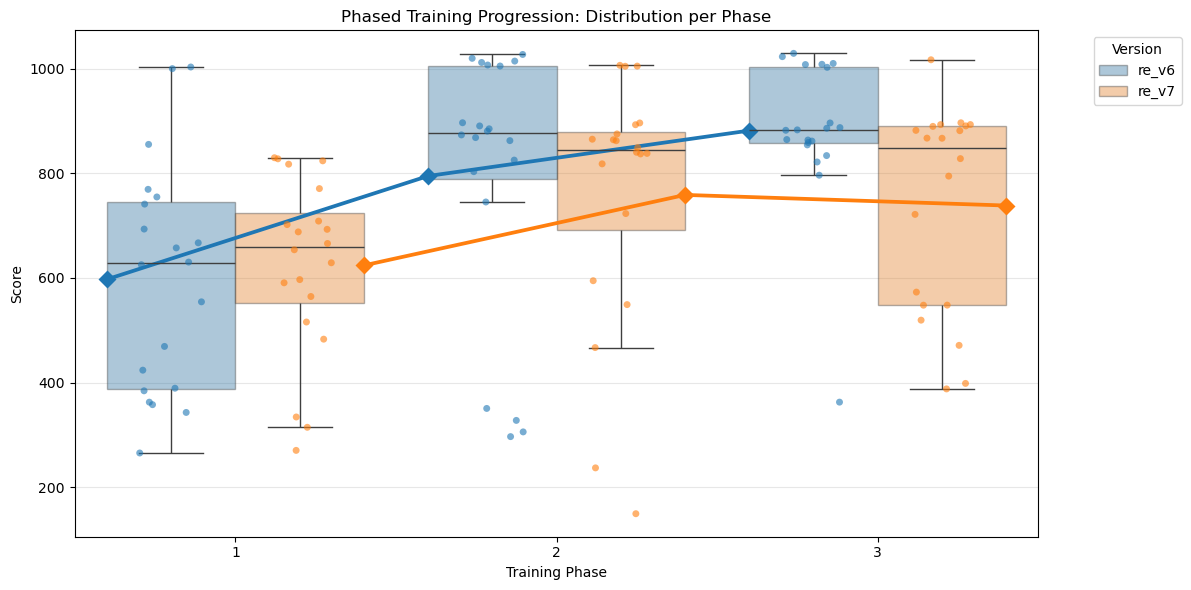

In [14]:
import re

# Filter for phased models
phased_df = df[df['Model Name'].str.contains('phase')].copy()

# Extract Version and Phase
def extract_phase_info(name):
    match = re.search(r'(re_v\d+)_phase_(\d+)', name)
    if match:
        return pd.Series([match.group(1), int(match.group(2))])
    return pd.Series([None, None])

phased_df[['Version', 'Phase']] = phased_df['Model Name'].apply(extract_phase_info)

# Plotting
plt.figure(figsize=(12, 6))

# Box Plot (Candle bar representation)
sns.boxplot(data=phased_df, x='Phase', y='Score', hue='Version', 
            showfliers=False, boxprops={'alpha': 0.4})

# Plot individual data points
sns.stripplot(data=phased_df, x='Phase', y='Score', hue='Version', 
              dodge=True, jitter=0.2, alpha=0.6, legend=False)

# Plot averages with connected lines
sns.pointplot(data=phased_df, x='Phase', y='Score', hue='Version', 
              dodge=0.8, markers='D', linestyles='-', errorbar=None, legend=False)

plt.title('Phased Training Progression: Distribution per Phase')
plt.ylabel('Score')
plt.xlabel('Training Phase')
plt.grid(True, axis='y', alpha=0.3)
plt.legend(title='Version', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

The visualization above clearly illustrates the impact of the phased training curriculum. For **v6** (blue), we observe a consistent upward trend in average performance (solid line) across all three phases, validating that the agent successfully transitioned from exploration to mastery. The box plots also reveal that while variance remains present, inherent to the unstable nature of the environment, the median performance improves significantly. In contrast, **v7** (orange) demonstrates a plateau in the final phase, visually confirming the "Lead Foot" issue where the agent failed to adapt to the higher speed requirements of the Mastery phase, resulting in frequent crashes and a lower ceiling compared to v6.

### Final considerations

All things considered, this project demonstrated the efficacy of a structured, curriculum-based approach to Reinforcement Learning in continuous control environments. While early iterations struggled with the classic "exploitation" of reward functions, that is, optimizing for speed at the cost of stability, the introduction of **Phased Training** proved to be the turning point. By decoupling the learning of steering dynamics from the learning of speed management, we achieved a model (`re_v6`) that is both fast and reliable.

Key takeaways include:
*   **Curriculum Learning is Critical**: The significant performance jump in v6 validates the strategy of gradually increasing task difficulty (target speed) and penalty severity.
*   **Reward Shaping requires Subtlety**: Our experiments showed that strict adherence to an "optimal line" can be detrimental if it forces the agent into unstable, high-frequency corrections. Relaxing these constraints allowed for smoother, more natural driving lines.
*   **Auxiliary Rewards are Guides, not Crutches**: The strong performance of the `no_line` model suggests that while the optimal line reward accelerates learning, the agent is capable of generalizing the concept of "track" without it.

Future improvements could involve implementing other algorithms such as **Soft Actor-Critic (SAC)** which has been reported to reach higher reward values in the CarRacing environments, or further refining the "Safe Steering" penalty to correct the braking behavior seen in `re_v7`.